# Lab 1 · EDA and simple baselines
Pairs · 24 September 2026, 12:30 Santiago · 6% NP.
Read the brief and rubric first. Supplied code supports execution; replace the written prompts and add your own analysis cells. MODE="synthetic" is fictional practice only. Real submission uses snapshot.

In [16]:
from pathlib import Path
import sys, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
for p in (Path.cwd(), *Path.cwd().parents):
    if (p/'labs/lab_01/lab01_support_v1.py').exists():
        ROOT=p; break
else:
    raise FileNotFoundError('Extract the full package and run inside it.')
sys.path.insert(0,str(ROOT/'labs/lab_01'))
from lab01_support_v1 import load_sources,merge_sources,majority_from_train,evaluate
MODE="snapshot"
print('DATA MODE:', MODE, '| Python:',platform.python_version(),'| pandas:',pd.__version__)

DATA MODE: snapshot | Python: 3.13.5 | pandas: 3.0.6


## 1. Target and audit

**Unit of observation:** one driver in one race.

**Prediction moment:** after qualifying has concluded and before the Grand Prix starts. At this
moment, qualifying_position is known; results-derived fields (position, points, laps, status)
are not yet known and cannot be used as predictors.

**Target:** target_top10 = 1 when the source's numeric final race position (results.position) is
between 1 and 10, inclusive; 0 otherwise. This measures final classification only. It is distinct
from completing the race (a driver can be classified without finishing all laps if they completed
enough distance) and from scoring points or contributing to a constructors' championship result.

**Population:** all driver/race records available in the supplied train snapshot (2019-2021),
obtained via a left join from results (the anchor table) onto qualifying, on (season, round,
driver_id). Retirements, non-finishers and rows with missing qualifying_position are kept. This
is a retrospective population drawn from currently available source records, not a verified,
complete list of every driver who was entered before each race started; some entries may be
absent from the source itself. The snapshots are historical records retrieved after the fact and
may include later corrections, so this is not a reconstruction of what was known at an exact
historical timestamp.

**Join direction and rationale:** starting from results and using how='left' guarantees every
race result is retained even when no matching qualifying row exists (qualifying_match ==
'left_only'). This matches the brief's population definition, which explicitly keeps entries with
missing qualifying records.

In [18]:
q_train,r_train=load_sources('train',ROOT,MODE)
train=merge_sources(q_train,r_train)
display(pd.DataFrame({'qualifying':q_train.groupby('season').size(),'results':r_train.groupby('season').size()}))
display(train.groupby('season').agg(rows=('driver_id','size'),missing_qualifying=('qualifying_position',lambda x:x.isna().sum())))
assert len(train)==len(r_train)
display(train['qualifying_match'].value_counts())

,qualifying,results
season,,
2019,418,420
2020,340,340
2021,439,440


,rows,missing_qualifying
season,,
2019,420,2
2020,340,0
2021,440,1


qualifying_match
both          1197
left_only        3
right_only       0
Name: count, dtype: int64

In [19]:
# Duplicate key checks
dup_q = q_train.duplicated(['season','round','driver_id']).sum()
dup_r = r_train.duplicated(['season','round','driver_id']).sum()
print('Duplicate keys in qualifying:', dup_q)
print('Duplicate keys in results:', dup_r)

# Inspect the unmatched (left_only) records
display(train[train['qualifying_match'] == 'left_only'][['season','round','driver_id','position','status','qualifying_position']])

Duplicate keys in qualifying: 0
Duplicate keys in results: 0


,season,round,driver_id,position,status,qualifying_position
49,2019,3,albon,10,+1 Lap,NaN
54,2019,3,giovinazzi,15,+1 Lap,NaN
857,2021,5,mick_schumacher,18,+3 Laps,NaN


Add checks for duplicate keys, qualifying-only records, missing values and coverage. Explain what would happen with an inner join. TO COMPLETE.

**Key and coverage audit (train, 2019-2021):**

- Duplicate keys: 0 duplicate (season, round, driver_id) combinations found in either the
  qualifying or results source tables — the join key is unique in both sources.
- Row counts: qualifying has 1197 rows, results has 1200 rows. The 3-row difference corresponds
  exactly to the qualifying_match == 'left_only' count.
- Missing qualifying after the join: 3 rows total (2 in 2019, 0 in 2020, 1 in 2021), affecting
  drivers who appear in the results table with no matching qualifying record.
- qualifying_match distribution: both = 1197, left_only = 3, right_only = 0. right_only is
  structurally impossible under a left join anchored on results, since only rows present in
  results can appear in the merged frame; a value of 0 here is a consequence of the join type,
  not evidence about the underlying data.
- Inspecting the three left_only rows individually: albon (2019, round 3, finished +1 lap,
  final position 10), giovinazzi (2019, round 3, finished +1 lap, final position 15), and
  mick_schumacher (2021, round 5, finished +3 laps, final position 18). All three drivers
  completed enough of the race to be classified (status shows lapped, not a retirement code),
  which indicates the missing qualifying_position is source missingness in the qualifying table
  itself rather than a data-quality issue linked to whether the driver finished. Notably, two of
  the three cases share the same race (2019, round 3), suggesting the gap may be localized to
  specific source-recording gaps for that event rather than spread evenly across the dataset.

**Effect of an inner join:** an inner join would keep only the 1197 'both' rows, dropping the 3
left_only records entirely — including albon's row, whose final position (10) falls inside the
target's positive class. This would shrink the evaluated population and silently exclude drivers
who raced (and in one case, scored a top-10 finish) but have no recorded qualifying position,
which the brief's population definition explicitly requires we keep. The left join therefore
better matches the stated population; the missing qualifying_position values are retained as
genuine missingness rather than dropped rows.

## 2. EDA question 1
Question: If we already know that nowadays winners are determined more by the car rather than the racer, then which constructors have the biggest presence on the top 10?

Use train only. Add a table/graph, cite observed values, interpret and state a decision or limitation. At least one of the three analyses must check a Friday trap.

Before making Question 1, we had to comprehend better the fields of the DataFrame, and what kind of information was inside it.

In [20]:
# Add your train-only analysis here.
# Step 1: Further understanding of the df and its contents
display(train.head())
display(train.info())
display(train.nunique())

,season,round,race_name,circuit_id,race_date,driver_id,driver_name,constructor_id,grid,position,position_text,status,points,laps,qualifying_position,qualifying_match,target_top10
0,2019,1,Australian Grand Prix,albert_park,2019-03-17,bottas,Valtteri Bottas,mercedes,2,1,1,Finished,26.0,58,2.0,both,1
1,2019,1,Australian Grand Prix,albert_park,2019-03-17,hamilton,Lewis Hamilton,mercedes,1,2,2,Finished,18.0,58,1.0,both,1
2,2019,1,Australian Grand Prix,albert_park,2019-03-17,max_verstappen,Max Verstappen,red_bull,4,3,3,Finished,15.0,58,4.0,both,1
3,2019,1,Australian Grand Prix,albert_park,2019-03-17,vettel,Sebastian Vettel,ferrari,3,4,4,Finished,12.0,58,3.0,both,1
4,2019,1,Australian Grand Prix,albert_park,2019-03-17,leclerc,Charles Leclerc,ferrari,5,5,5,Finished,10.0,58,5.0,both,1


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   season               1200 non-null   int64   
 1   round                1200 non-null   int64   
 2   race_name            1200 non-null   str     
 3   circuit_id           1200 non-null   str     
 4   race_date            1200 non-null   str     
 5   driver_id            1200 non-null   str     
 6   driver_name          1200 non-null   str     
 7   constructor_id       1200 non-null   str     
 8   grid                 1200 non-null   int64   
 9   position             1200 non-null   int64   
 10  position_text        1200 non-null   str     
 11  status               1200 non-null   str     
 12  points               1200 non-null   float64 
 13  laps                 1200 non-null   int64   
 14  qualifying_position  1197 non-null   float64 
 15  qualifying_match     1200 non-nu

None

season                  3
round                  22
race_name              34
circuit_id             29
race_date              60
driver_id              28
driver_name            28
constructor_id         13
grid                   21
position               20
position_text          23
status                 39
points                 23
laps                   72
qualifying_position    20
qualifying_match        2
target_top10            2
dtype: int64

Among all the available columns, there was one that received our attention: constructor_id. It was highlighted because, according to what was said on class, today a good vehicle has more chances to win than a talented driver. So, we used it along with the first ten positions.

In [21]:
# Step 2: extracting relevant data to study
constructors = train['constructor_id'].unique()
positionstxt = train['position_text'].unique()
positionstxt10 = positionstxt[:10]
print(constructors)
print(positionstxt)
print(positionstxt10)

<StringArray>
[    'mercedes',     'red_bull',      'ferrari',         'haas',
      'renault',         'alfa', 'racing_point',   'toro_rosso',
      'mclaren',     'williams',   'alphatauri', 'aston_martin',
       'alpine']
Length: 13, dtype: str
<StringArray>
[ '1',  '2',  '3',  '4',  '5',  '6',  '7',  '8',  '9', '10', '11', '12', '13',
 '14', '15', '16', '17',  'R', '18', '19', '20',  'D',  'W']
Length: 23, dtype: str
<StringArray>
['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
Length: 10, dtype: str


After clarifying the elements of both central colunms, we counted the frequency of every combination to determine the amount of times each constructor was on the top 10.

In [22]:
# Step 3: matching the two variables
trainCnstr = pd.crosstab(train['constructor_id'], train['position_text'])
trainCnstr1 = trainCnstr[positionstxt10]
display(trainCnstr1)

position_text,1,2,3,4,5,6,7,8,9,10
constructor_id,,,,,,,,,,
alfa,0,0,0,1,1,0,3,4,7,8
alphatauri,1,0,1,4,3,7,8,3,6,6
alpine,1,0,1,2,1,3,3,5,9,4
aston_martin,0,1,0,0,2,1,2,4,2,4
ferrari,3,10,14,16,13,10,8,8,0,7
haas,0,0,0,0,0,1,2,1,2,3
mclaren,1,2,5,7,17,13,10,11,8,8
mercedes,37,27,21,6,5,2,3,3,2,0
racing_point,1,1,2,5,2,6,8,3,8,6


Finally, because both variables are categorical and a bar plot would be too saturated, we decided to use a heatmap.

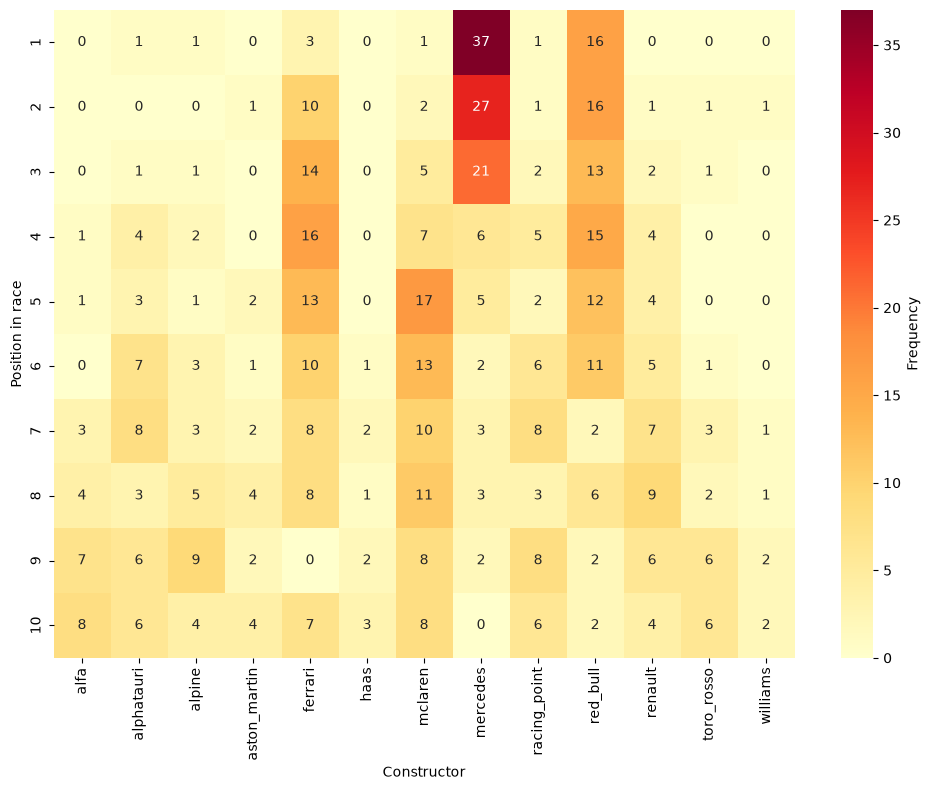

In [23]:
# Step 4: Visualizing the results
plt.figure(figsize=(10, 8))
sns.heatmap(trainCnstr1.T, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Frequency'})
plt.xlabel('Constructor')
plt.ylabel('Position in race')
plt.tight_layout()
plt.show()

**Cited values:** we noticed that there are four teams (Ferrari, McClaren, Mercedes, and Red Bull) that had frequencies of at least fifteen. All those values are over the top 5.

**Answer:** The constructor that most highlighted on the top 10 is MERCEDES, because it's the only one that has red elements (in other words, it obtained that position the most times), all of them on the three first places.

**Decision:** In case of investing or bets, the best choice is pointing the resources toward Mercedes, due to all its mayor victories.

## 3. EDA question 2
Question: Is there a relation between the each rank of the grid and the position results?

Use train only. Add a table/graph, cite observed values, interpret and state a decision or limitation. At least one of the three analyses must check a Friday trap.

We repited the process from Question 1 and, among all the available columns, there was one that received our attention: grid. It was highlighted because, according to what was said on class, the place where a driver starts usually matches the one on which he finishes. So, we used it along with the first ten positions.

In [25]:
# Add your train-only analysis here.
# # Step 1: extracting relevant data to study
grids = train['grid'].unique()
print(grids)
grids.sort()
print(grids)

[ 2  1  4  3  5  7 11  9 16 15 17  8 10 13 14 19 20  6 12 18  0]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


After clarifying the elements of both central colunms, we counted the frequency of every combination to determine the amount of times each beginning grid had a racer on the top 10.

In [26]:
# Step 2: matching the two variables
trainGrid = pd.crosstab(train['grid'], train['position_text'])
trainGrid1 = trainGrid[positionstxt10]
display(trainGrid1)

position_text,1,2,3,4,5,6,7,8,9,10
grid,,,,,,,,,,
0,0,0,0,0,2,0,0,1,0,4
1,29,13,6,2,0,0,2,1,2,0
2,15,20,8,2,2,2,0,2,1,0
3,8,11,19,6,1,2,3,0,2,1
4,2,6,11,16,6,4,4,0,1,1
5,1,2,5,11,9,6,4,3,2,2
6,2,1,3,4,6,16,8,2,4,1
7,0,3,1,1,7,6,11,4,2,4
8,1,0,1,7,9,4,5,3,5,4


Finally, because both variables are categorical and a bar plot would be too saturated, we decided to use a heatmap.

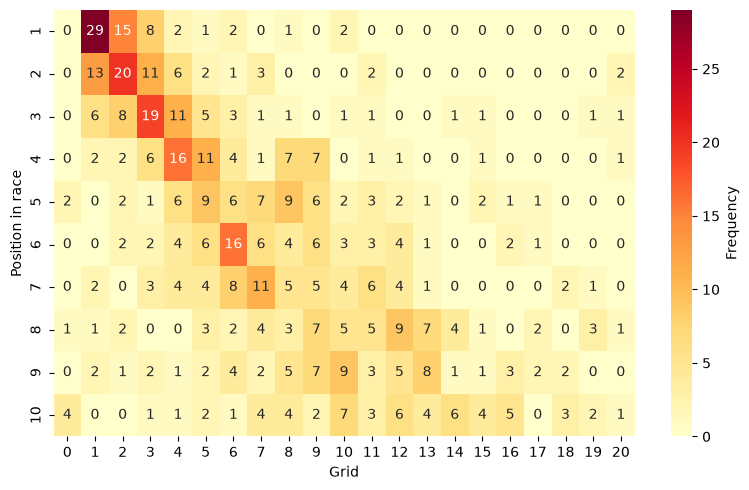

In [27]:
# Step 3: Visualizing the results
plt.figure(figsize=(8, 5))
sns.heatmap(trainGrid1.T, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Frequency'})
plt.xlabel('Grid')
plt.ylabel('Position in race')
plt.tight_layout()
plt.show()

**Cited values:** we noticed that the colors become stronger toward the upper-left corner.

**Answer:** There is a relation between the grid and the final position, almost the one of an inverse proportion. It happens because the more match the numbers of both variables, the more frequent are the combinations. 

**Decision:** In case of investing or bets, the best choice is pointing the resources toward the grid's first place, due to all its mayor victories.

## 4. EDA question 3
Question: Are the qualifying positions before the race similar to the ones of the results?

Use train only. Add a table/graph, cite observed values, interpret and state a decision or limitation. At least one of the three analyses must check a Friday trap.

We repited the process from Question 1 & 2 and, among all the available columns, there was one that received our attention: qualifying position. It was highlighted because it determines the grid and, along with it, the results. So, we used it along with the first ten positions.

In [28]:
# Add your train-only analysis here.
# # Add your train-only analysis here.
# # Step 1: extracting relevant data to study
qualifying = train['qualifying_position'].unique()
print(qualifying)
qualifying.sort()
print(qualifying)

[ 2.  1.  4.  3.  5.  7. 11.  9. 16. 15. 17.  8. 10. 13. 14. 19. 20.  6.
 12. 18. nan]
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. nan]


After clarifying the elements of both central colunms, we counted the frequency of every combination to determine the amount of times each beginning Qualifying rank had a racer on the top 10.

In [29]:
# Step 2: matching the two variables
trainQual = pd.crosstab(train['qualifying_position'], train['position_text'])
trainQual1 = trainQual[positionstxt10]
display(trainQual1)

position_text,1,2,3,4,5,6,7,8,9,10
qualifying_position,,,,,,,,,,
1.0,30,13,6,1,1,1,2,1,2,0
2.0,13,17,9,5,3,2,0,2,1,0
3.0,8,14,16,5,0,1,3,0,2,1
4.0,3,6,14,16,5,3,4,0,0,1
5.0,2,3,5,10,11,4,3,3,2,1
6.0,1,0,2,4,6,19,9,1,3,0
7.0,1,3,2,2,10,6,7,4,4,4
8.0,1,0,1,7,6,3,5,3,2,6
9.0,0,0,0,6,5,7,5,5,9,3


Finally, because both variables are categorical and a bar plot would be too saturated, we decided to use a heatmap.

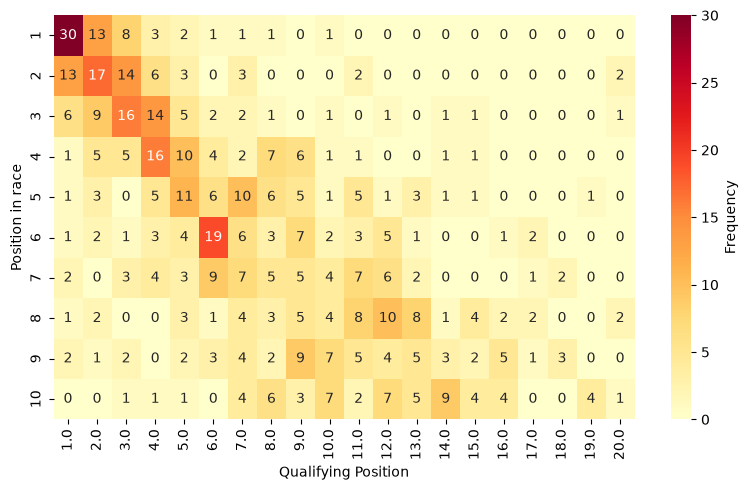

In [30]:
# Step 3: Visualizing the results
plt.figure(figsize=(8, 5))
sns.heatmap(trainQual1.T, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Frequency'})
plt.xlabel('Qualifying Position')
plt.ylabel('Position in race')
plt.tight_layout()
plt.show()

**Cited values:** we noticed that the colors become stronger toward the upper-left corner, but they might be more concentrated than in Question 2.

**Answer:** There is a relation between the qualifying and the final position, almost the one of an inverse proportion. It happens because the more match the numbers of both variables, the more frequent are the combinations. However, those frequencies aren't the same than in Question 2.

**Decision:** In case of investing or bets, the best choice is pointing the resources toward the first Qualifying Position, due to all its mayor victories.

### Friday trap check


**Misleading correlation:** the heatmap's strong diagonal invites reading
qualifying_position as a *cause* of the final result, but the observed relationship is a
correlation, not a demonstrated causal effect. Several confounders could produce this pattern
without qualifying "causing" the outcome: faster cars tend to both qualify and finish well
(car performance is a shared cause of both variables), grid penalties can move a driver away
from their qualifying slot, and mechanical failures or collisions during the race can break the
relationship regardless of starting position. This also carries a graphical-framing risk: heatmap
color intensity draws attention to the diagonal and visually exaggerates how deterministic the
relationship looks, when many off-diagonal cells (upsets, retirements, safety-car chaos) are still
present. For this reason, a rule such as "qualifying_position <= 10 predicts top 10" should be read
as a useful heuristic supported by correlation, not as a guarantee grounded in a causal mechanism.

## 5. Baselines and 2022 check

**Training majority:** predicts the single most frequent value of target_top10 across all of
train (2019-2021), applied to every row regardless of any driver-specific information. An exact
50/50 tie predicts 0 by convention. This rule is never recomputed on calibration or test — the
majority value is frozen at whatever train produces.

**Qualifying top ten:** predicts 1 when qualifying_position <= 10, and 0 otherwise. When
qualifying_position is missing, the rule falls back to the frozen training majority rather than
guessing a value from the outcome itself; we report how many rows use that fallback for
transparency.

**Qualitative failure prediction (before running the check):**
- The training majority is expected to perform poorly on any individual driver, since it ignores
  qualifying entirely; if target_top10's base rate in train is close to 50%, balanced accuracy
  should sit near chance level (~0.5).
- The qualifying top ten rule is expected to outperform the majority whenever qualifying position
  is a meaningful proxy for pace, but it should still misclassify races with retirements,
  penalties, or safety-car-driven upsets, since it cannot see any of that information at the
  prediction moment.
- Both rules are expected to degrade somewhat from train to calibration (2022), since car and
  driver line-ups change year to year and neither rule was tuned on 2022 data.

In [31]:
majority=majority_from_train(train)
print('Training majority:',majority,'| training target rate:',train.target_top10.mean())
q_cal,r_cal=load_sources('calibration',ROOT,MODE)
cal=merge_sources(q_cal,r_cal)
print('Calibration rows:',len(cal),'| missing qualifying:',cal.qualifying_position.isna().sum())
display(evaluate(cal,majority))

Training majority: 0 | training target rate: 0.5
Calibration rows: 440 | missing qualifying: 0


,n,TN,FP,FN,TP,accuracy,balanced_accuracy
majority,440.0,220.0,0.0,220.0,0.0,0.500000,0.500000
qualifying_top10,440.0,168.0,52.0,52.0,168.0,0.763636,0.763636


**Calibration interpretation (2022):**

- Training majority predicts 0 (not top 10) for every one of the 440 calibration rows, exactly as
  frozen from train, where the target rate was exactly 0.5 (an exact tie, so the rule predicts 0
  by convention). This produces TN=220, FP=0, FN=220, TP=0: it never predicts a top-10 finish, so
  it perfectly avoids false positives but misses every true positive. Accuracy and balanced
  accuracy both land at 0.500, which is exactly chance level — expected, since the rule uses no
  information about the specific race.

- Qualifying top ten shows TN=168, FP=52, FN=52, TP=168, giving accuracy=0.764 and
  balanced_accuracy=0.764 (identical because the calibration set happens to be perfectly balanced,
  220 positives and 220 negatives). Notably, 0 rows used the missing-qualifying fallback this year
  (unlike train, which had 3 missing rows), so this result reflects the qualifying-position rule
  directly, with no fallback effect.

- **False positives** (52 rows) mean the rule predicted a top-10 finish for a driver who did not
  achieve it — qualifying inside the top 10 but finishing outside it, likely due to retirements,
  poor race pace, or incidents that qualifying position cannot foresee. **False negatives** (52
  rows) mean the rule predicted no top-10 finish for a driver who did achieve one — qualifying
  outside the top 10 but finishing inside it, likely due to strong race pace, strategy, or other
  drivers' retirements opening up positions. The two error types are exactly balanced here (52
  each), so neither failure mode dominates in this calibration set.

- The qualifying top ten rule clearly outperforms the training majority (balanced accuracy 0.764
  vs. 0.500), confirming the qualitative prediction made before running this check: qualifying
  position carries real signal about the final result, but is far from perfect, missing roughly
  1 in 4 cases in both directions.

- No correction was needed after this calibration check: both rules ran as specified, the
  fallback logic behaved correctly (triggering 0 times, consistent with 0 missing qualifying
  values this year), and no bug was found in the implementation.

## 6. Freeze before final test

- **Members and date:** Martin Olivares and Benjamin Levit, 23 September 2026.

- **Target, population, join and prediction moment:** target_top10 = 1 when the source's numeric
  final race position (results.position) is between 1 and 10, inclusive; 0 otherwise. Population
  is all driver/race records available in the supplied snapshots, built via a left join from
  results (anchor table) onto qualifying, on (season, round, driver_id); retirements,
  non-finishers and rows with missing qualifying_position are kept. Prediction moment is after
  qualifying has concluded and before the Grand Prix starts; only qualifying_position is available
  as a predictor at this moment, not any results-derived field (position, points, laps, status).

- **Baselines, train majority, threshold and missing policy:** training majority = 0 (frozen from
  2019-2021, where the target rate was exactly 0.5 — an exact tie, predicting 0 by convention).
  Qualifying top ten predicts 1 when qualifying_position <= 10, else 0; when qualifying_position
  is missing, it falls back to the frozen training majority (0). This threshold and fallback are
  fixed for comparability and are not changed based on calibration or test outcomes.

- **Three analysis decisions and changes after calibration:** the three EDA questions (constructor
  vs. top-10 presence, grid vs. final position, qualifying position vs. final position) were
  completed using train only (2019-2021), including one explicit trap check (misleading
  correlation/graphical framing on the qualifying-vs-result heatmap). No changes to the target,
  join, baselines, or threshold were made after reviewing the 2022 calibration results; the
  qualifying top ten rule performed as qualitatively predicted (balanced accuracy 0.764 vs. 0.500
  for the majority), and no implementation bug was found, so nothing was corrected or retuned.

- **Frozen code commit/version:**

In [ ]:
RUN_TEST=False
if RUN_TEST:
    q_test,r_test=load_sources('test',ROOT,MODE,frozen=True)
    test=merge_sources(q_test,r_test)
    print('Test rows:',len(test),'| missing qualifying:',test.qualifying_position.isna().sum())
    display(evaluate(test,majority))
else:
    print('Test remains unopened by this notebook. Complete and commit the freeze record first.')

## 7. Final interpretation and handoff
Compare calibration and test, cite your observed results, explain one failure mode and what the evidence supports. Discuss the retrospective population and source timing limitation. TO COMPLETE.

Complete RUNBOOK and PROMPTS/contributions; restart/run all and save outputs. Submit the repository URL and final commit via Canvas. No separate report is required.